# Decision Tree — Strategy B: Random Undersampling

A Decision Tree classifier is trained using random undersampling to balance the training data by reducing the number of majority-class samples. This strategy allows the model to focus more equally on diabetes and non-diabetes cases. Hyperparameter tuning is used to control tree complexity and improve generalization, while the final evaluation is performed on the original imbalanced test set.

In [1]:
import numpy as np
import pandas as pd
import shap
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [3]:
pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(random_state=42)),
    ("model", DecisionTreeClassifier(
        modelclass_weight='balanced',
        modelcriterion='entropy',
        modelmax_depth=7,
        modelmax_features=None,
        modelmin_samples_leaf=20,
        modelmin_samples_split=2,
        random_state=42
        ))
])

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__max_features": [None, "sqrt"],
    "model__class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

TypeError: DecisionTreeClassifier.__init__() got an unexpected keyword argument 'modelclass_weight'

## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

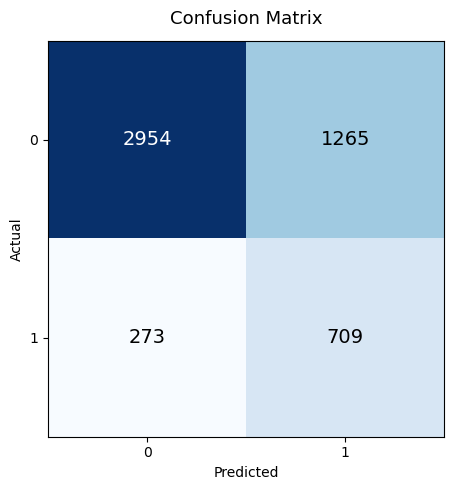

In [4]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_final)

y_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix", color="black", fontsize=13, pad=12)
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

for text in disp.text_.ravel():
    text.set_color("black")
    text.set_fontsize(14)
disp.text_[0, 0].set_color("white")

plt.tight_layout()
plt.show()

In [5]:
# Results

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7043
ROC AUC: 0.7797
Confusion Matrix:
[[2954 1265]
 [ 273  709]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.70      0.79      4219
         1.0       0.36      0.72      0.48       982

    accuracy                           0.70      5201
   macro avg       0.64      0.71      0.64      5201
weighted avg       0.81      0.70      0.73      5201



## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [6]:
metrics = {

    "Strategy": "Undersampling",

    "Model": "Decision Tree",

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_pred_proba)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/decision_tree_undersampling_metrics.csv", index=False)

## XAI Feature Importance

- SHAP
- Permutation importance
- Built-in Decision Tree feature importance

All results are exported for cross-model comparison.

## SHAP

In [ ]:
# SHAP feature importance

shap_explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = shap_explainer.shap_values(X_test_final)

shap_fi = np.abs(shap_values).mean(axis=0)
shap_rank = shap_fi.rank(ascending=False, method="first").astype(int)

shap_df = pd.DataFrame({
    "model": "Decision Tree",
    "strategy": "Random Undersampling",
    "method": "SHAP",
    "feature": X_test_final.columns,
    "importance": shap_fi,
    "rank": shap_rank
})

shap_df.to_csv("../RESULTS/FEATURE IMPORTANCE/decision_tree_undersampling_shap.csv", index=False)


NameError: name 'best_model' is not defined

## Permutation

In [ ]:
# Permutation importance
feature_names = X_test_final.columns

perm_result = permutation_importance(
    estimator=best_model,
    X=X_test_final,
    y=y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_importance = perm_result.importances_mean
perm_top_index = int(np.argmax(perm_importance))

xai_permutation_df = pd.DataFrame([{
    "model": "Decision Tree",
    "strategy": "Random Undersampling",
    "method": "Permutation",
    "feature": feature_names[perm_top_index],
    "importance": float(perm_importance[perm_top_index]),
    "rank": 1
}])

xai_permutation_df.to_csv("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_permutation.csv", index=False)

from pathlib import Path
method_files = [
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_shap.csv"),
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_permutation.csv"),
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_builtin.csv")
]
available = [pd.read_csv(f) for f in method_files if f.exists()]
if available:
    pd.concat(available, ignore_index=True).to_csv(
        "../RESULTS/PERFORMANCE/decision_tree_undersampling_xai.csv",
        index=False
    )

xai_permutation_df

## Built in

In [ ]:
# Built-in Decision Tree feature importance
tree_model = best_model.named_steps["model"]
feature_names = X_test_final.columns
builtin_importance = tree_model.feature_importances_
builtin_top_index = int(np.argmax(builtin_importance))

xai_builtin_df = pd.DataFrame([{
    "model": "Decision Tree",
    "strategy": "Random Undersampling",
    "method": "Built-in",
    "feature": feature_names[builtin_top_index],
    "importance": float(builtin_importance[builtin_top_index]),
    "rank": 1
}])

xai_builtin_df.to_csv("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_builtin.csv", index=False)

from pathlib import Path
method_files = [
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_shap.csv"),
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_permutation.csv"),
    Path("../RESULTS/PERFORMANCE/decision_tree_undersampling_xai_builtin.csv")
]
available = [pd.read_csv(f) for f in method_files if f.exists()]
if available:
    pd.concat(available, ignore_index=True).to_csv(
        "../RESULTS/PERFORMANCE/decision_tree_undersampling_xai.csv",
        index=False
    )

xai_builtin_df